--- k-Nearest Neighbors Classification ---

Processing for k = 1...
Point x51 (value: 0.9696) -> Class2
Point x52 (value: 0.7751) -> Class2
Point x53 (value: 0.9395) -> Class2
Point x54 (value: 0.8948) -> Class2
Point x55 (value: 0.5979) -> Class2

Processing for k = 2...
Point x51 (value: 0.9696) -> Class2
Point x52 (value: 0.7751) -> Class2
Point x53 (value: 0.9395) -> Class2
Point x54 (value: 0.8948) -> Class2
Point x55 (value: 0.5979) -> Class2

Processing for k = 3...
Point x51 (value: 0.9696) -> Class2
Point x52 (value: 0.7751) -> Class2
Point x53 (value: 0.9395) -> Class2
Point x54 (value: 0.8948) -> Class2
Point x55 (value: 0.5979) -> Class2

Processing for k = 4...
Point x51 (value: 0.9696) -> Class2
Point x52 (value: 0.7751) -> Class2
Point x53 (value: 0.9395) -> Class2
Point x54 (value: 0.8948) -> Class2
Point x55 (value: 0.5979) -> Class2

Processing for k = 5...
Point x51 (value: 0.9696) -> Class2
Point x52 (value: 0.7751) -> Class2
Point x53 (value: 0.9395) -> Class2
Poin

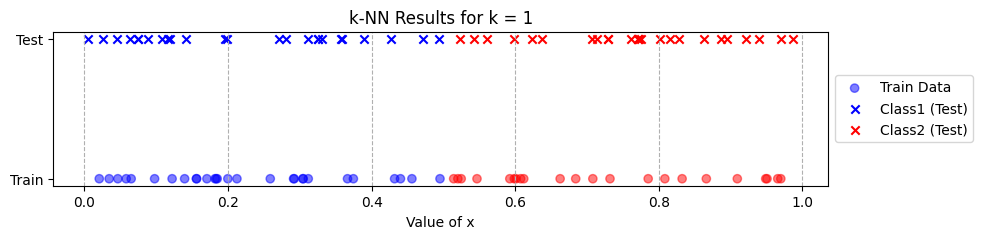

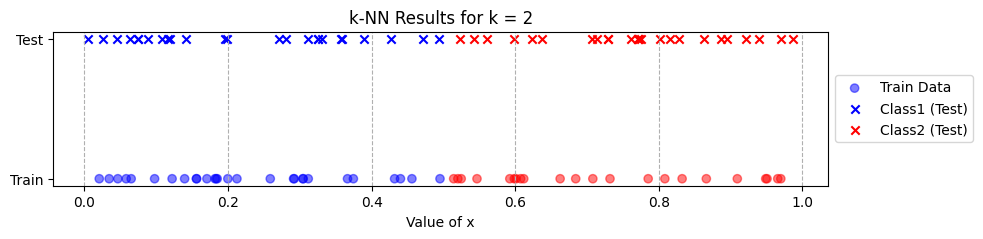

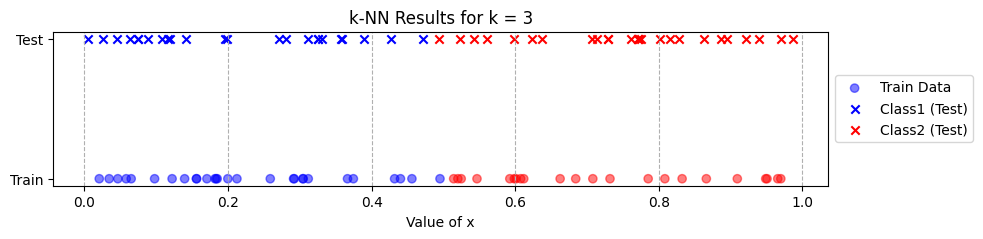

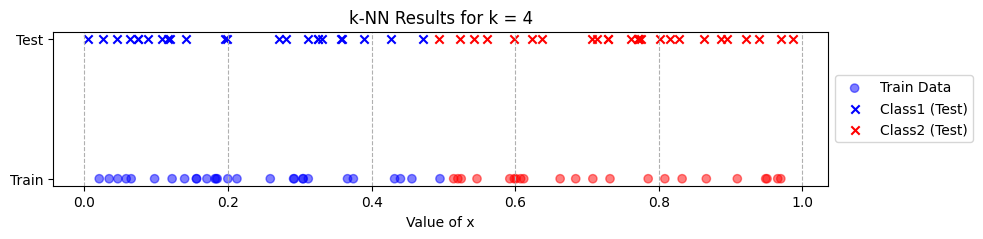

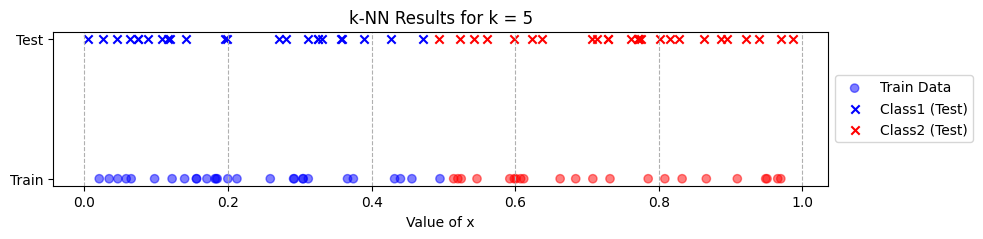

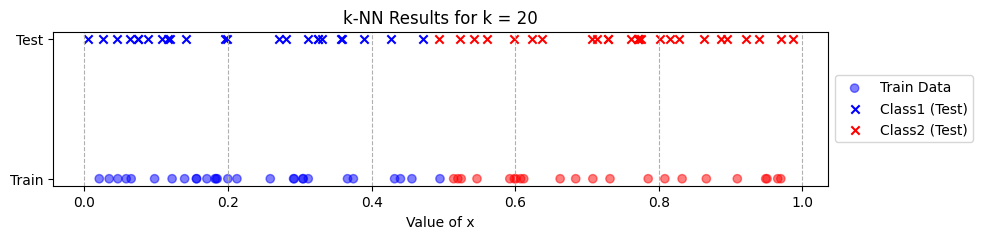

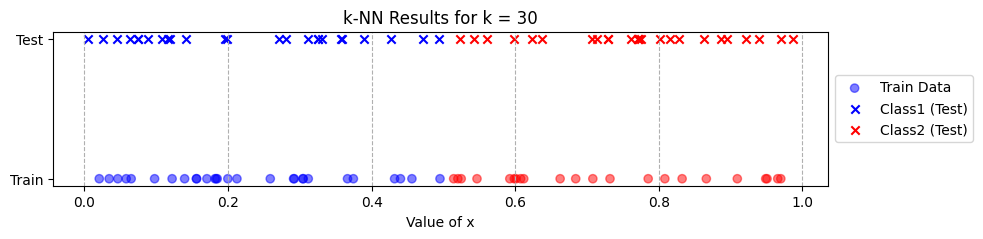

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# Step 1: Generate 100 random values in the range [0, 1]
np.random.seed(42) # Optional: keeps results consistent every time you run it
data = np.random.rand(100)

# Label the first 50 points based on the rule: x <= 0.5 is Class1, else Class2
# FIX: The manual had a typo "else Class1", it should be "Class2"
train_data = data[:50]
train_labels = ["Class1" if x <= 0.5 else "Class2" for x in train_data]

# The remaining 50 points are our test data
test_data = data[50:]

# Step 2: Define Distance and Classifier Functions
def euclidean_distance(x1, x2):
    return abs(x1 - x2)

def knn_classifier(train_data, train_labels, test_point, k):
    # Calculate distances from test_point to all training points
    distances = []
    for i in range(len(train_data)):
        dist = euclidean_distance(test_point, train_data[i])
        distances.append((dist, train_labels[i]))
    
    # Sort by distance (ascending)
    distances.sort(key=lambda x: x[0])
    
    # Get the labels of the k nearest neighbors
    k_nearest_neighbors = distances[:k]
    k_nearest_labels = [label for _, label in k_nearest_neighbors]
    
    # Return the most common label among neighbors
    return Counter(k_nearest_labels).most_common(1)[0][0]

# Step 3: Run classification for different k values
k_values = [1, 2, 3, 4, 5, 20, 30]
results = {}

print("--- k-Nearest Neighbors Classification ---")

for k in k_values:
    print(f"\nProcessing for k = {k}...")
    classified_labels = [knn_classifier(train_data, train_labels, tp, k) for tp in test_data]
    results[k] = classified_labels
    
    # Optional: Print first few results for each k to save space in Jupyter
    for i in range(5):
        print(f"Point x{i+51} (value: {test_data[i]:.4f}) -> {classified_labels[i]}")

# Step 4: Visualization
for k in k_values:
    classified_labels = results[k]
    
    # Separate points for plotting
    class1_test = [test_data[i] for i in range(len(test_data)) if classified_labels[i] == "Class1"]
    class2_test = [test_data[i] for i in range(len(test_data)) if classified_labels[i] == "Class2"]
    
    plt.figure(figsize=(10, 2)) # Shorter height since it's 1D data
    
    # Plot Training Data on the bottom line (y=0)
    train_colors = ["blue" if l == "Class1" else "red" for l in train_labels]
    plt.scatter(train_data, [0] * len(train_data), c=train_colors, label="Train Data", marker="o", alpha=0.5)
    
    # Plot Test Results on the top line (y=1)
    if class1_test:
        plt.scatter(class1_test, [1] * len(class1_test), c="blue", label="Class1 (Test)", marker="x")
    if class2_test:
        plt.scatter(class2_test, [1] * len(class2_test), c="red", label="Class2 (Test)", marker="x")
        
    plt.title(f"k-NN Results for k = {k}")
    plt.yticks([0, 1], ["Train", "Test"])
    plt.xlabel("Value of x")
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.grid(axis='x', linestyle='--')
    plt.show()

--- k-Nearest Neighbors Classification ---
Training dataset: First 50 points labeled based on rule
Testing dataset: Remaining 50 points

Results for k = 1:
Point x51 (value: 0.2009) is classified as Class1
Point x52 (value: 0.6559) is classified as Class2
Point x53 (value: 0.4004) is classified as Class1
Point x54 (value: 0.3369) is classified as Class1
Point x55 (value: 0.8907) is classified as Class2
Point x56 (value: 0.5649) is classified as Class2
Point x57 (value: 0.3794) is classified as Class1
Point x58 (value: 0.3225) is classified as Class1
Point x59 (value: 0.7876) is classified as Class2
Point x60 (value: 0.6573) is classified as Class2
Point x61 (value: 0.7663) is classified as Class2
Point x62 (value: 0.6035) is classified as Class2
Point x63 (value: 0.4860) is classified as Class1
Point x64 (value: 0.0096) is classified as Class1
Point x65 (value: 0.6493) is classified as Class2
Point x66 (value: 0.4502) is classified as Class1
Point x67 (value: 0.5249) is classified as C

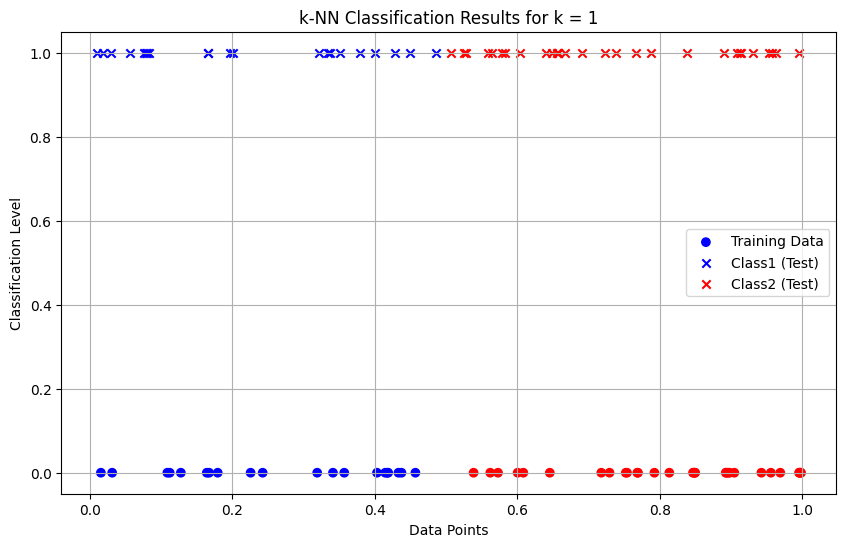

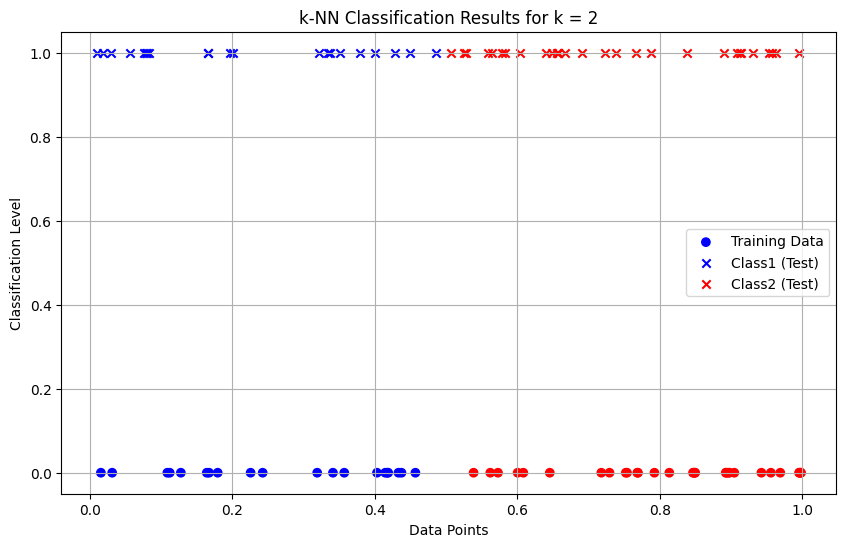

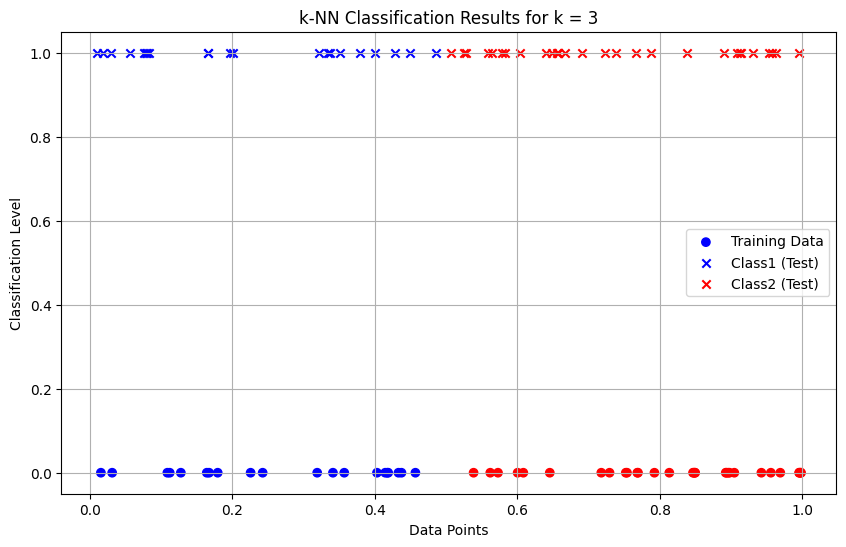

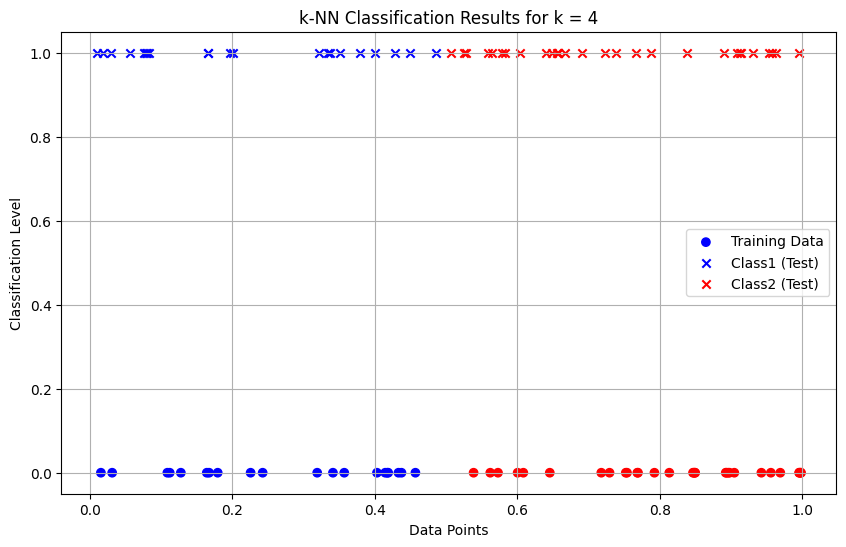

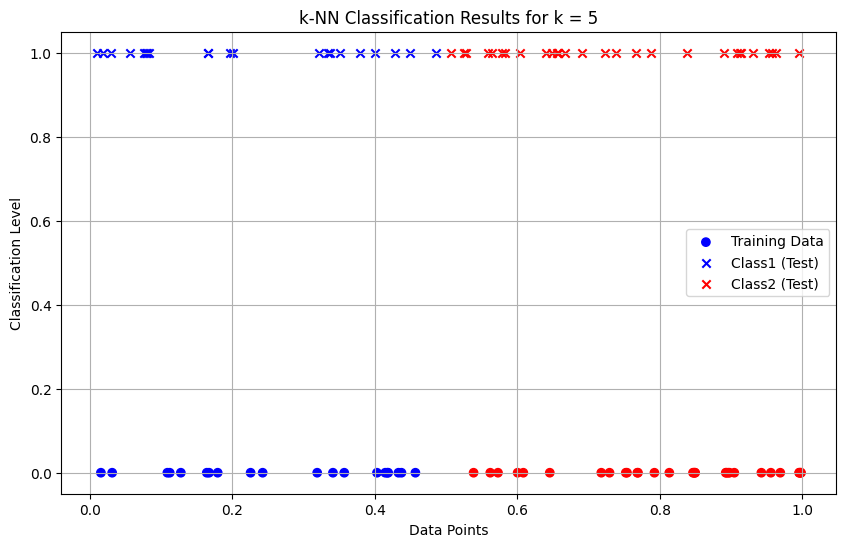

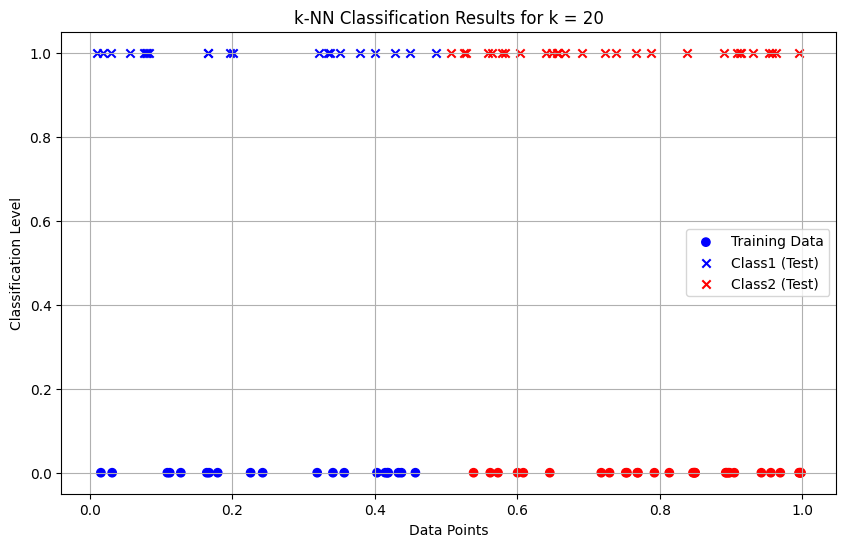

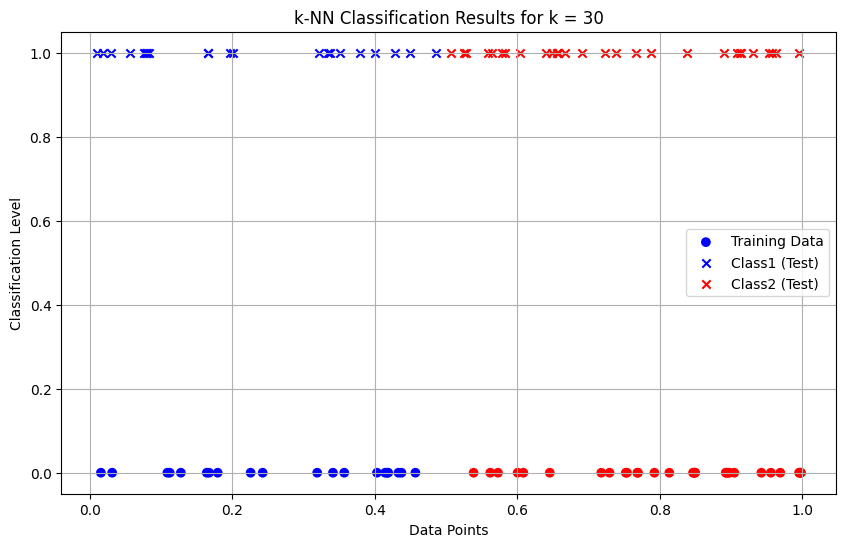

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# Generate random data
data = np.random.rand(100)

# Label first 50 points
labels = ["Class1" if x <= 0.5 else "Class2" for x in data[:50]]

# Distance function
def euclidean_distance(x1, x2):
    return abs(x1 - x2)

# KNN classifier
def knn_classifier(train_data, train_labels, test_point, k):
    distances = [(euclidean_distance(test_point, train_data[i]), train_labels[i]) 
                 for i in range(len(train_data))]
    
    distances.sort(key=lambda x: x[0])
    
    k_nearest_neighbors = distances[:k]
    k_nearest_labels = [label for _, label in k_nearest_neighbors]
    
    return Counter(k_nearest_labels).most_common(1)[0][0]

# Split data
train_data = data[:50]
train_labels = labels
test_data = data[50:]

k_values = [1, 2, 3, 4, 5, 20, 30]

print("--- k-Nearest Neighbors Classification ---")
print("Training dataset: First 50 points labeled based on rule")
print("Testing dataset: Remaining 50 points\n")

results = {}

# Classification
for k in k_values:
    print(f"Results for k = {k}:")
    
    classified_labels = [knn_classifier(train_data, train_labels, test_point, k) 
                         for test_point in test_data]
    
    results[k] = classified_labels
    
    for i, label in enumerate(classified_labels, start=51):
        print(f"Point x{i} (value: {test_data[i - 51]:.4f}) is classified as {label}")
    
    print("\n")

print("Classification complete.\n")

# Plotting
for k in k_values:
    classified_labels = results[k]
    
    class1_points = [test_data[i] for i in range(len(test_data)) 
                     if classified_labels[i] == "Class1"]
    
    class2_points = [test_data[i] for i in range(len(test_data)) 
                     if classified_labels[i] == "Class2"]
    
    plt.figure(figsize=(10, 6))
    
    # Training data
    plt.scatter(train_data, [0]*len(train_data),
                c=["blue" if label == "Class1" else "red" for label in train_labels],
                label="Training Data", marker="o")
    
    # Test data
    plt.scatter(class1_points, [1]*len(class1_points),
                c="blue", label="Class1 (Test)", marker="x")
    
    plt.scatter(class2_points, [1]*len(class2_points),
                c="red", label="Class2 (Test)", marker="x")
    
    plt.title(f"k-NN Classification Results for k = {k}")
    plt.xlabel("Data Points")
    plt.ylabel("Classification Level")
    plt.legend()
    plt.grid(True)
    plt.show()